# 2 — Methods and results

All four methods, run here on one image so the behaviour is visible, then the
aggregate numbers loaded from the single evaluation run.

Nothing in this notebook recomputes a published number. The table and the
figures come from `results/metrics/unified_results.json`, which
`src/evaluate.py` wrote in one pass over the held-out test split. If this
notebook and the README ever disagree, both are reading the same file and one
of them is stale.


In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
%matplotlib inline


In [2]:
import cv2, numpy as np
from pycocotools.coco import COCO
from ultralytics import YOLO
from config import ANN_FILE, IMG_DIR, BEST_WEIGHTS, CONF, IOU_NMS
from baseline import watershed_segmentation, kmeans_color_segmentation
from hybrid import hybrid_predict, yolo_masks, edge_density

coco = COCO(str(ANN_FILE))
split = json.loads((ROOT / "results" / "metrics" / "data_split.json").read_text())
img_id = split["test"][0]
info = coco.loadImgs(img_id)[0]
image = cv2.cvtColor(cv2.imread(str(IMG_DIR / info["file_name"])), cv2.COLOR_BGR2RGB)
gt = [coco.annToMask(a).astype(bool) for a in coco.loadAnns(coco.getAnnIds(imgIds=img_id, iscrowd=False))]

model = YOLO(str(BEST_WEIGHTS))
print(f"image {img_id}  ·  {image.shape[1]}x{image.shape[0]}  ·  {len(gt)} ground-truth objects")
print(f"Canny edge density: {edge_density(image):.4f}")


loading annotations into memory...


Done (t=0.60s)
creating index...
index created!
image 504415  ·  640x427  ·  8 ground-truth objects
Canny edge density: 0.2549


In [3]:
ws = watershed_segmentation(image)
km = kmeans_color_segmentation(image)
yl = yolo_masks(model, image, CONF, IOU_NMS)
hy = hybrid_predict(model, image)

for name, n in [("ground truth", len(gt)), ("watershed", len(ws)),
                ("kmeans", len(km)), ("yolo", len(yl)), ("hybrid", hy["count"])]:
    print(f"{name:<14} {n}")
print(f"\ndensity gate fired: {hy['dense']}   watershed blend applied: {hy['blended']}")


ground truth   8
watershed      4
kmeans         142
yolo           5
hybrid         6

density gate fired: True   watershed blend applied: False


Watershed under-counts and KMeans over-counts, both badly, and both for
structural reasons rather than tuning ones — Otsu needs a bimodal intensity
histogram that a natural photograph does not have, and colour clustering has no
object prior at all. Those failures are the reason the project exists.


In [4]:
import matplotlib.pyplot as plt
from figures import SURFACE, INK

def overlay(img, masks, alpha=0.55):
    from figures import SERIES
    pal = np.array([[42,120,214],[235,104,52],[27,175,122],[237,161,0],
                    [232,123,164],[0,131,0],[74,58,167],[227,73,72]], dtype=np.uint8)
    out = img.copy()
    for i, m in enumerate(masks):
        out[m] = (alpha * pal[i % len(pal)] + (1 - alpha) * out[m]).astype(np.uint8)
    return out

panels = [("Ground truth", gt), ("Watershed", ws), ("YOLOv8s-seg", yl), ("Hybrid", hy["masks"])]
fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for ax, (title, masks) in zip(axes, panels):
    ax.imshow(overlay(image, masks)); ax.axis("off")
    ax.set_title(f"{title}  ({len(masks)})", color=INK)
fig.tight_layout(); plt.show()


## Aggregate results — the single evaluation run

In [5]:
res = json.loads((ROOT / "results" / "metrics" / "unified_results.json").read_text())
p = res["provenance"]
print(f"experiment v{p['experiment_version']}  ·  {p['date']}  ·  seed {p['seed']}  ·  device {p['device']}")
print(f"test images: {p['n_test_images']}   IoU matching: {p['iou_match_mode']}   tolerance: +/-{p['count_tolerance']}")
print(f"torch {p['torch']}  ultralytics {p['ultralytics']}  weights {p['weights']}\n")

import pandas as pd
rows = []
for k, label in [("watershed","Watershed"),("kmeans","KMeans"),
                 ("yolo","YOLOv8s-seg (fine-tuned)"),("hybrid","Hybrid (density-aware)")]:
    s = res["summary"][k]
    rows.append({"Method": label, "Mean IoU": s["mean_iou"],
                 "Count Acc %": s["count_accuracy_pct"], "MAE": s["mae"],
                 "Median ms": s["median_inference_ms"]})
pd.DataFrame(rows).set_index("Method")


experiment v2.0  ·  2026-09-22  ·  seed 1337  ·  device cuda
test images: 50   IoU matching: greedy_class_agnostic   tolerance: +/-3
torch 2.11.0+cu128  ultralytics 8.4.38  weights yolov8s-seg-dense.pt



,Mean IoU,Count Acc %,MAE,Median ms
Method,,,,
Watershed,0.0653,28.0,8.66,13.3
KMeans,0.2516,0.0,114.86,87.8
YOLOv8s-seg (fine-tuned),0.4287,52.0,4.28,26.1
Hybrid (density-aware),0.4559,64.0,3.30,61.6


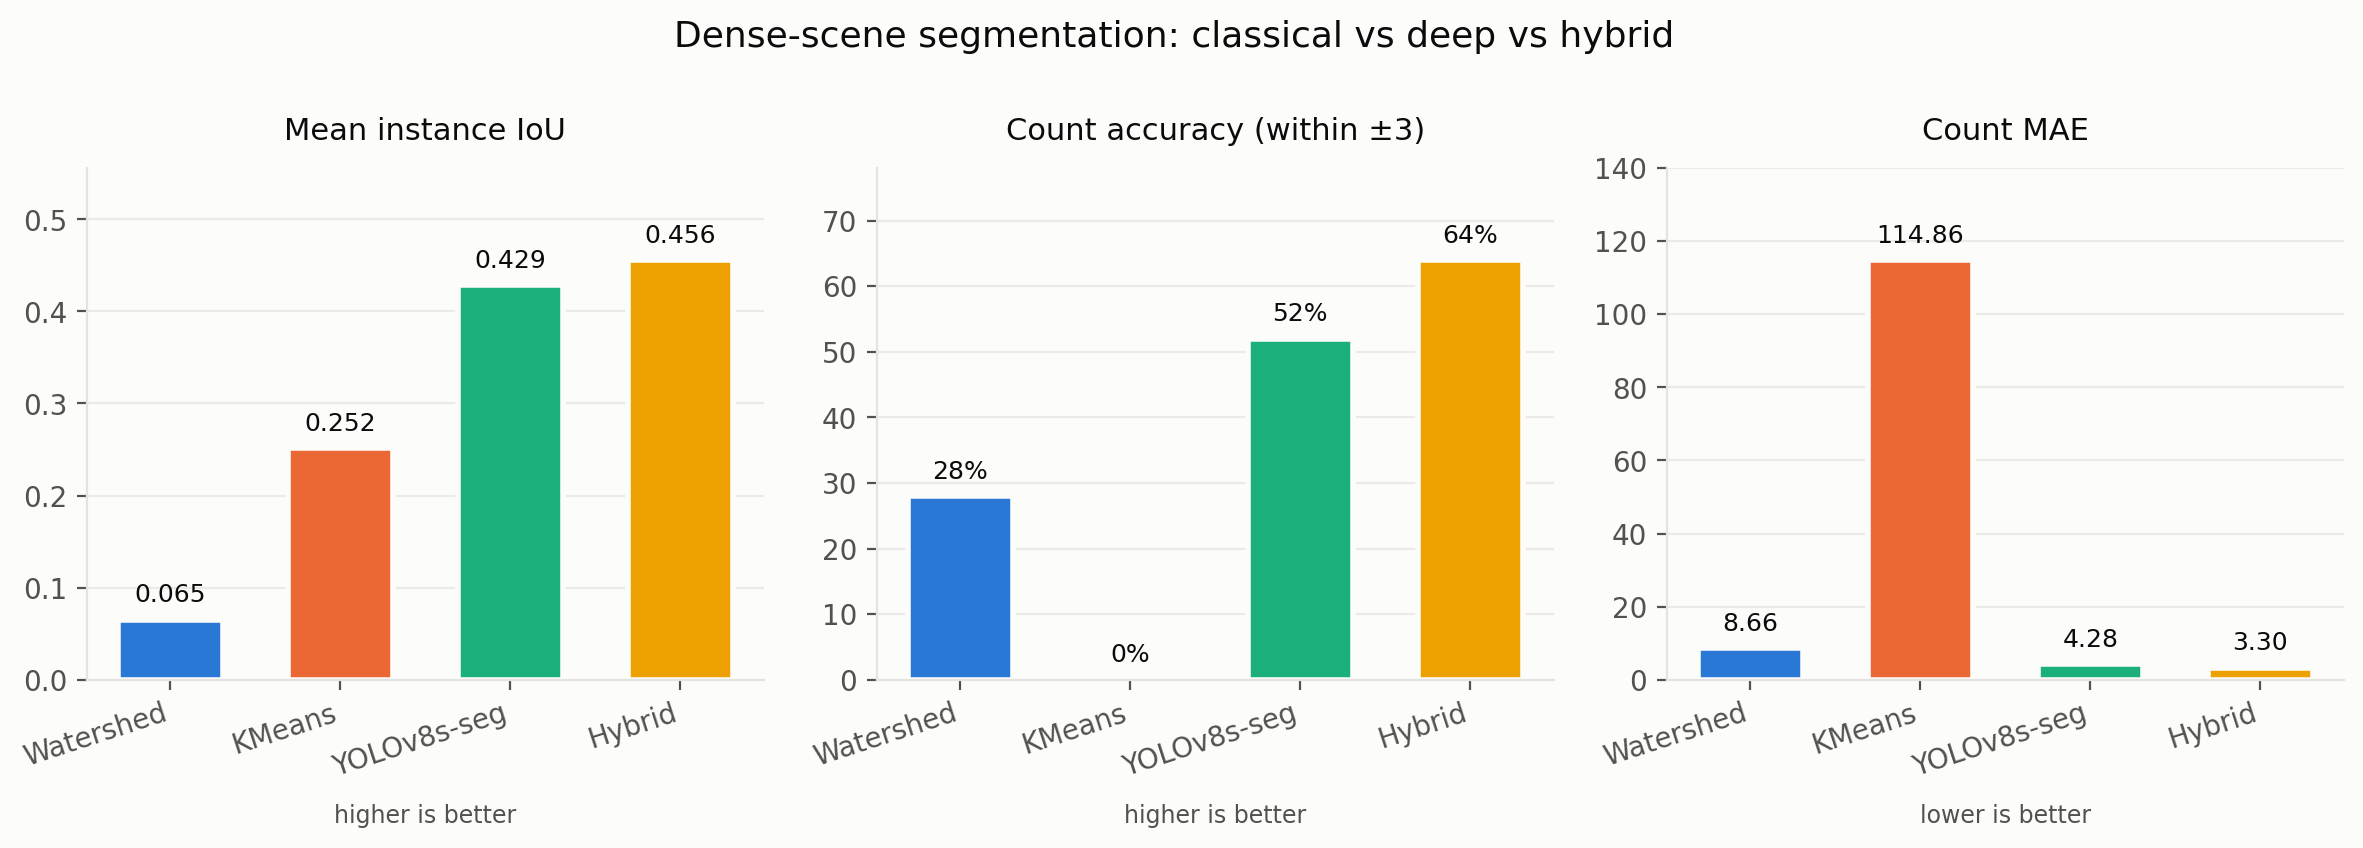

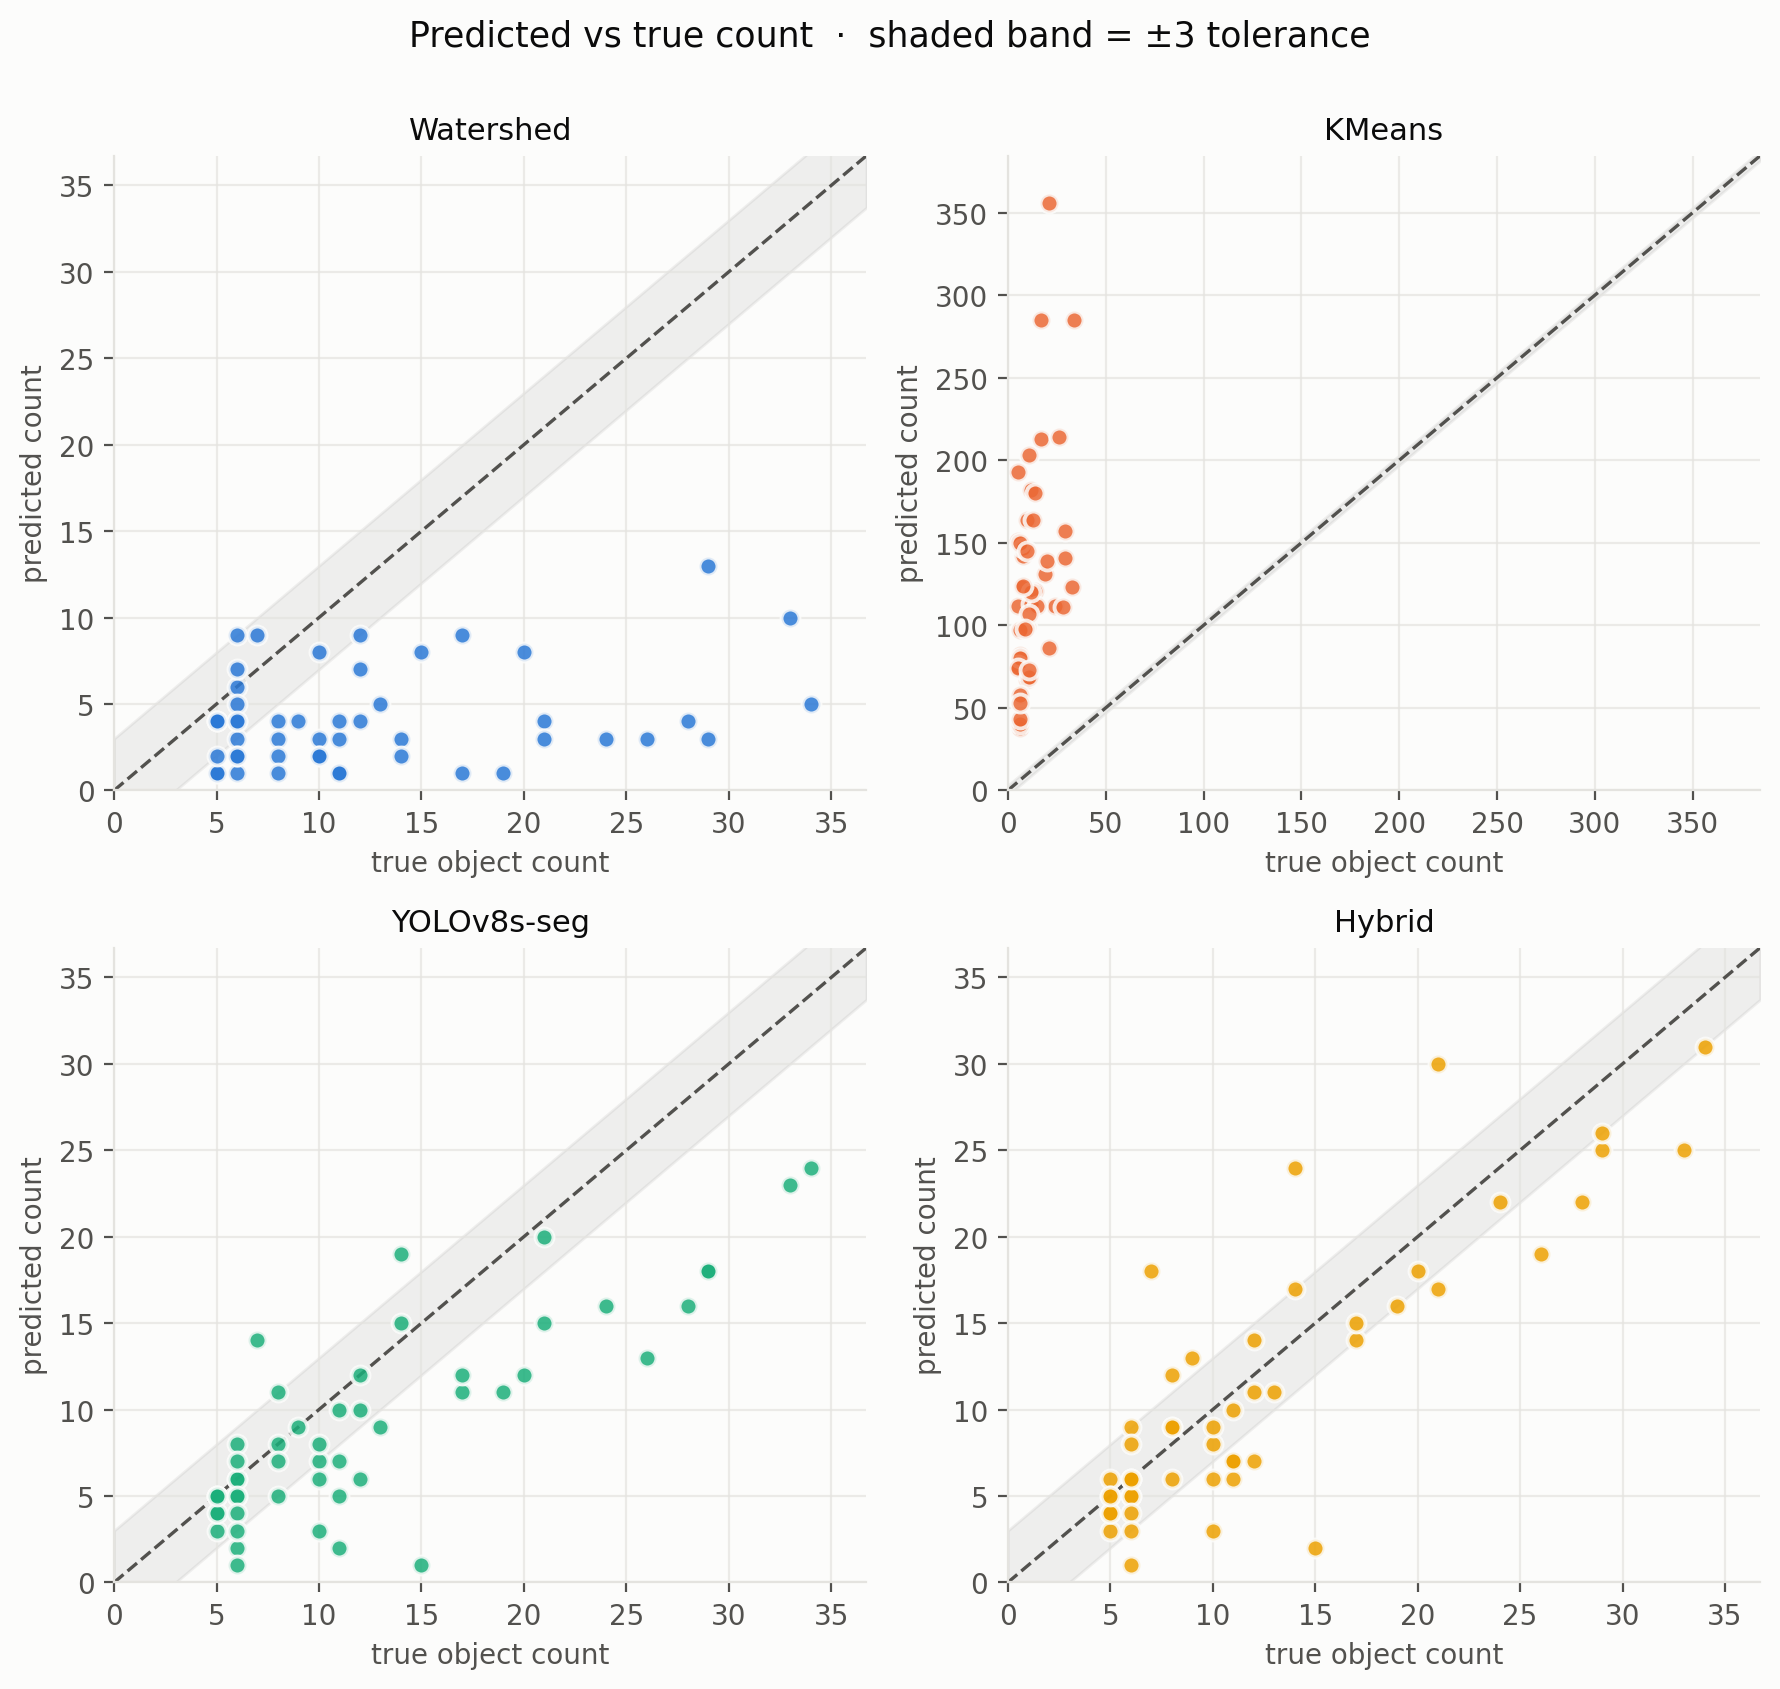

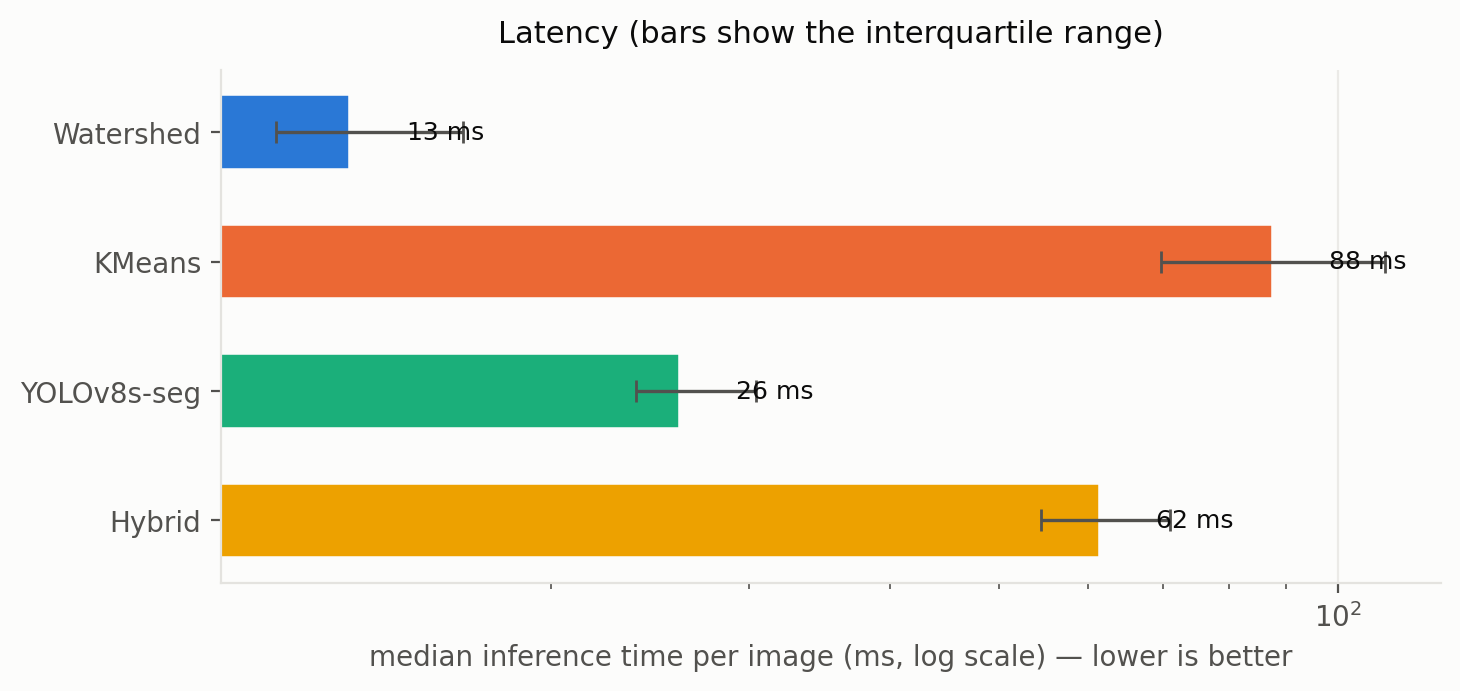

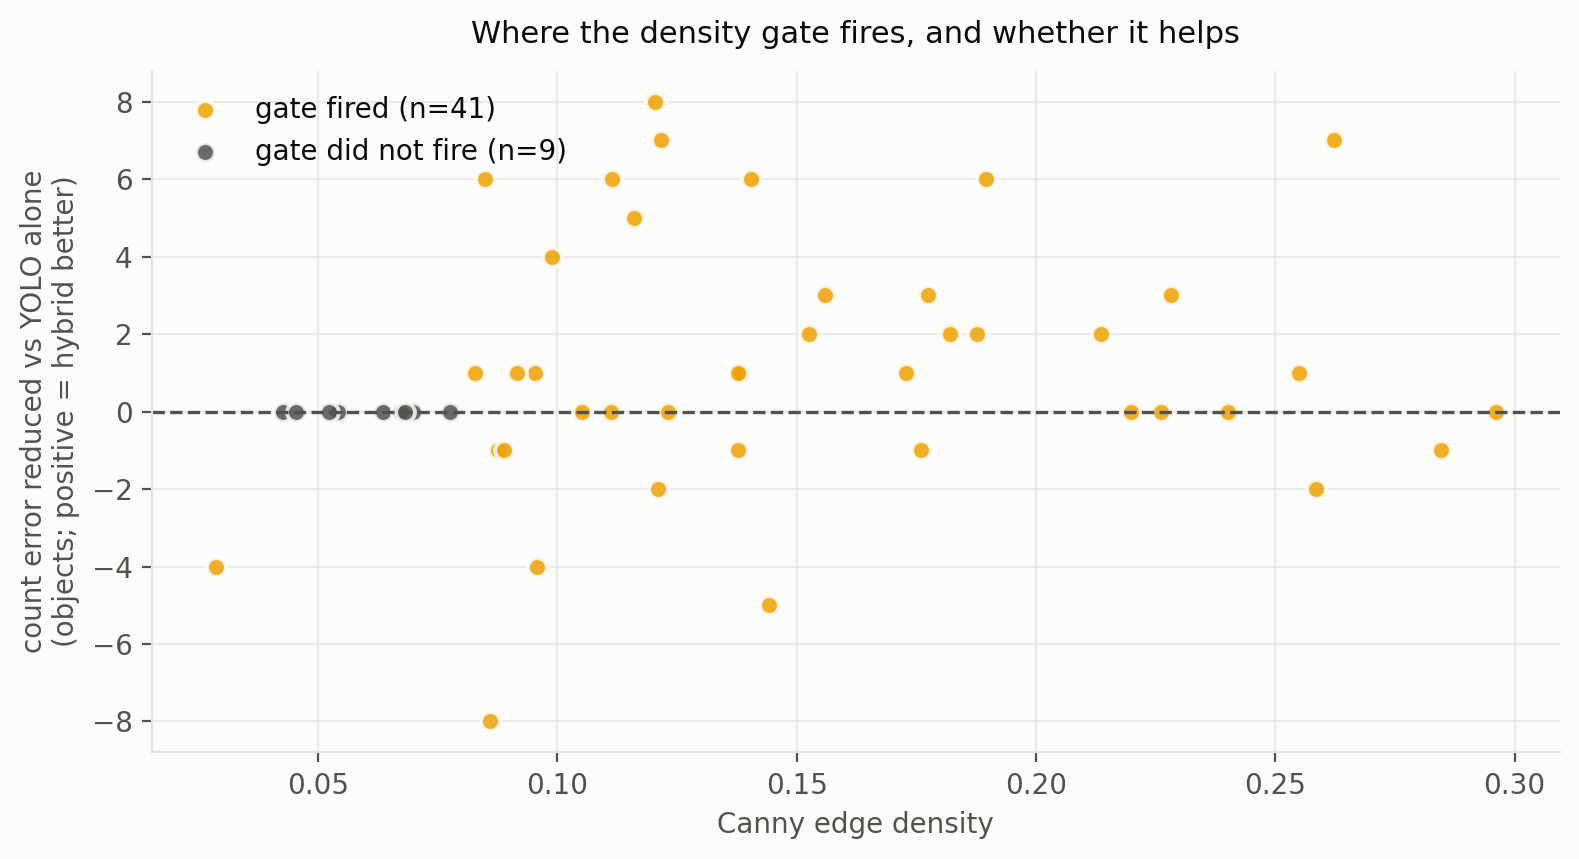

In [6]:
from IPython.display import Image, display
for name in ["comparison.png", "count_scatter.png", "inference_time.png", "density_gate.png"]:
    display(Image(filename=str(ROOT / "results" / "figures" / name)))
